In [34]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import imageio.v2 as imageio

## PART 1: Raytracer

In [5]:
RED=np.array([1.0, 0.0, 0.0])
GREEN=np.array([0.0, 1.0, 0.0])
BLUE=np.array([0.0, 0.0, 1.0])
WHITE=np.array([1.0, 1.0, 1.0])

In [6]:
class Sphere():
    def __init__(self, center, color, r=None):
        self.c = np.asarray(center)
        self.color = np.asarray(color)
        self.r = r

    # adapted from jamesbowman/raytrace
    def intersect(self, origin, direction):
        if self.r is None:
            f = 1.0 - origin[2]
            z = self.c[2] - origin[2]
            r = 0.05 * z / f
        else:
            r = self.r
        
        b = 2 * np.dot(direction, (origin - self.c))
        c1 = self.c @ self.c
        c2 = origin @ origin
        c3 = self.c @ origin
        c4 = r * r
        c = c1 + c2 - 2 * c3 - c4
        disc = b * b - 4 * c
        sq = np.sqrt(np.maximum(0, disc))
        h0 = (-b - sq) / 2
        h1 = (-b + sq) / 2
        h = np.where((h0 > 0) & (h0 < h1), h0, h1)
        pred = (disc > 0) & (h > 0)
        return np.where(pred, h, np.inf)

In [49]:
## Rendering
def raytrace(origin, direction, scene):
    distances = np.array([s.intersect(origin, direction) for s in scene])
    nearest = np.min(distances, axis=0)
    color = np.zeros((direction.shape[0], 3))  # R=0 G=0 B=0
    for (s, d) in zip(scene, distances):
        hit = (nearest != np.inf) & (d == nearest)
        color[hit] = s.color
    return color

def render(scene, camera, w=128, h=128, step=0.1, frames=4, f=1.0):
    r = float(w) / h
    screen = (-1, 1 / r + .25, 1, -1 / r + .25)
    x = np.tile(np.linspace(screen[0], screen[2], w), h)
    y = np.repeat(np.linspace(screen[1], screen[3], h), w)

    q = np.column_stack((x, y, np.full_like(x, f)))
    images = np.empty((frames, h, w, 3))
    c = np.copy(camera)

    for i in range(frames):
        direction = q / np.linalg.norm(q, axis=1, keepdims=True)
        images[i] = raytrace(c, direction, scene).reshape(h, w, 3)
        c += np.array([0.0, 0.0, step])

    return images

def display(images):
    n_frames = images.shape[0]
    fig, axes = plt.subplots(
        1, n_frames,
        figsize=(3 * n_frames, 3.2),
        facecolor="#ffffff"
    )
    fig.subplots_adjust(wspace=0.04)
    
    if n_frames == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    plt.show()

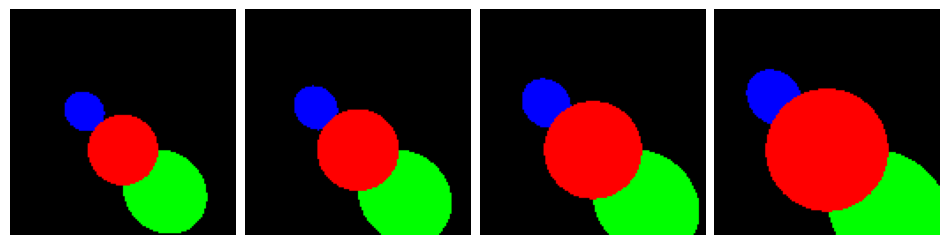

In [55]:
scene = [Sphere([0.0, 0.0, 2.0],  RED,   0.6),
         Sphere([1.0, -1.0, 3.0], GREEN, 1.0),
         Sphere([-1.0, 1.0, 3.0], BLUE,  0.5)]
camera = np.array([0.0, 0.0, 0.0])

images = render(scene, camera, step=0.25)
display(images)

## PART 2: Dataset

In [56]:
def dot_scene(distance, count=200, spread_xy=1.0, depth_jitter=1.0,
                   min_radius=0.01, max_radius=0.03):
    scene = []

    for _ in range(count):
        x = random.uniform(-spread_xy, spread_xy)
        y = random.uniform(-spread_xy, spread_xy)
        z = random.uniform(distance - depth_jitter, distance + depth_jitter)
        r = min_radius + (max_radius - min_radius) * (random.random() ** 2)
        scene.append(Sphere([x, y, z], WHITE, None))

    return scene

def array_to_gif(
    frames: np.ndarray,
    output_path: str,
    fps: float = 10,
    loop: int = 0,
) -> None:
    if frames.dtype != np.uint8:
        if np.issubdtype(frames.dtype, np.floating):
            frames = np.clip(frames, 0.0, 1.0) * 255
        else:
            frames = np.clip(frames, 0, 255)
        frames = frames.astype(np.uint8)
    frames_hw = np.transpose(frames, (0, 2, 1, 3))

    duration_ms = int(1000 / fps)

    imageio.mimsave(
        output_path,
        frames_hw,
        format="GIF",
        duration=duration_ms / 1000.0,
        loop=loop,
    )

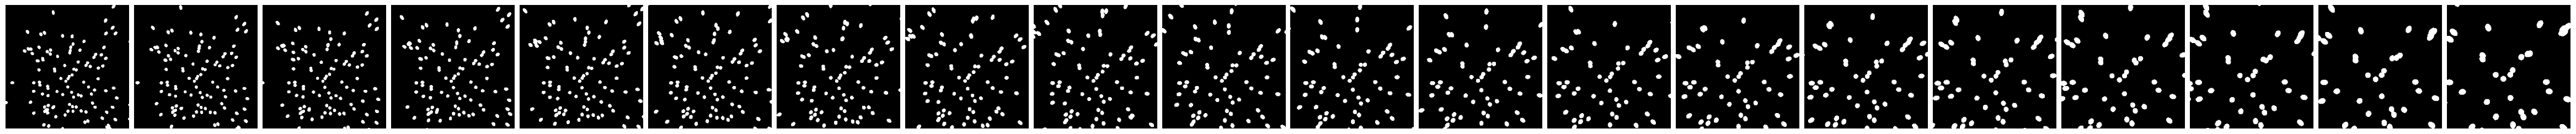

In [61]:
## Near scene
scene = dot_scene(0.0)
camera = np.array([0.0, 0.0, -1.0])

images = render(scene, camera, w=256, h=256, step=0.05, frames=20)
display(images)

array_to_gif(images, "near.gif", fps=8)

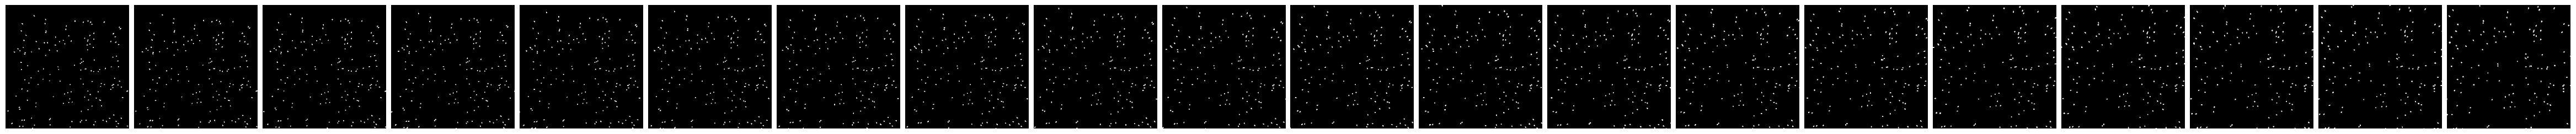

In [67]:
## Far scene
scene = dot_scene(0.0, spread_xy=5.0)
camera = np.array([0.0, 0.0, -5.0])

images = render(scene, camera, 256, 256, step=0.05, frames=20)
display(images)

array_to_gif(images, "far.gif", fps=8)

## PART 3: Waves

In [72]:
def make_coordinate_grid(grid_size):
    coords = np.arange(grid_size)
    return np.meshgrid(coords, coords, indexing="xy")

def normalize_frame(frame):
    frame = np.clip(frame, 0.0, None)
    max_val = frame.max()
    if max_val > 0:
        frame = frame / max_val
    return frame

def expanding_ring_sequence(
    grid_size=256,
    n_frames=4,
    noise_std=0.05,
    noise_mean=0.0,
    clip=True
):
    xx, yy = make_coordinate_grid(grid_size)

    center = (grid_size - 1) / 2
    cx = center + np.random.uniform(-grid_size / 2, grid_size / 2)
    cy = center + np.random.uniform(-grid_size / 2, grid_size / 2)

    rr = np.hypot(xx - cx, yy - cy)
    r0 = np.random.uniform(grid_size / 12, grid_size / 4)
    dr = np.random.uniform(grid_size / 12, grid_size / 8)
    width = np.random.uniform(grid_size / 12, grid_size / 10)

    rt = r0 + dr * np.arange(n_frames)[:, None, None]
    frames = np.exp(-((rr - rt) ** 2) / (2 * width**2))

    frames = np.stack([normalize_frame(frame) for frame in frames], axis=0)

    noise = np.random.normal(loc=noise_mean, scale=noise_std, size=frames.shape)
    frames = frames + noise

    if clip:
        frames = np.clip(frames, 0.0, 1.0)

    return frames

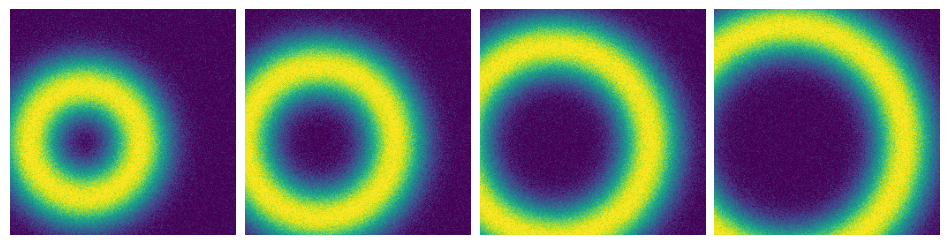

In [78]:
display(expanding_ring_sequence())